# Bayesian Optimal Experimental Design — Burgers Equation Tutorial

This notebook demonstrates our BOED proposal on the 1D viscous Burgers equation.
The pipeline covers:
1. **Setup** — PDE model, noise, and discretisation
2. **Prior** — GP prior split into parameter of interest $\theta$ and nuisance $\eta$
3. **Forward model** — $G:(\theta)\mapsto u(\cdot,T)$
4. **Finite-difference Jacobians** — $J_\theta$ and their Monte-Carlo expectations
5. **Covariance matrices** — $\Sigma_Y$, $\Sigma_{\rm noise}$, $\Sigma_{\rm signal}$, $\Sigma_{Y|\theta}$
6. **EIG estimators** — upper bound (BS) and direct estimator (BI)
7. **Greedy sensor placement** comparison

## 1. Imports

In [391]:
import numpy as np
import numpy.linalg as la
import scipy.linalg as sla
import matplotlib.pyplot as plt
from scipy.stats import qmc, norm, multivariate_normal
from joblib import Parallel, delayed

from boed.priors.kernels import Matern32, Matern12
from boed.priors.gp_priors import GaussianProcessPrior
from boed.core.noise import NoiseModel, ColoredNoise
from boed.core import make_u0
from boed.pde.burgers import Burgers_CN
from boed.utils.observation import build_selection_matrices

## 2. Setup

We define the spatial grid, PDE model, true initial condition, and observation noise.

In [392]:
np.random.seed(42)

N        = 200      # number of interior grid points
dt       = 0.001
n_steps  = 100
sigma    = 0.1   # noise standard deviation
lambda_  = 0.75
n_samples = 500

x_grid = np.linspace(0, 1, N + 2)[1:-1]

model   = Burgers_CN(N=N, dt=dt, diffusivity=0.02, lambda_=lambda_)
u0_true = make_u0(x_grid, "gaussian", center=0.25, width=0.07, amplitude=1.5)
noise   = NoiseModel(sigma_noise=sigma)
Sigma_obs = noise.get_covariance(N)

## 3. Prior

The joint parameter $\theta \in \mathbb{R}^{d}$ follows a Gaussian prior:

$$
\theta \sim \mathcal{N}\!\left(m_{\theta},\;
\Sigma_{\theta} \right)
$$


In [393]:
kernel = Matern32(length_scale=0.2, sigma=1.0)
prior  = GaussianProcessPrior(kernel, mu=np.zeros(N), nx=N)

In [394]:
def _halton_normal(d: int, n: int, seed: int | None = None) -> np.ndarray:
    sampler = qmc.Halton(d=d, scramble=True, seed=seed)
    u = sampler.random(n=n)
    eps = np.finfo(float).eps
    return norm.ppf(np.clip(u, eps, 1.0 - eps))


def sample_prior(prior, n: int, seed: int | None = None) -> np.ndarray:
    mu = np.asarray(prior.mu)
    L  = np.linalg.cholesky(np.asarray(prior.Sigma))
    z  = _halton_normal(len(mu), n, seed=seed)
    return mu + (L @ z.T).T


In [395]:
# ----------------------------------------------------------------------
# 1.  Prior via KL expansion
# ----------------------------------------------------------------------
class KLPrior:
    """
    Prior = N(mu, Sigma) → représentation KL tronquée.
    theta = mu + V_k @ diag(sqrt(lam_k)) @ xi,   xi ~ N(0, I_k)
    """
    def __init__(self, mu, Sigma, energy=0.99998):
        self.mu_full = np.asarray(mu)
        ev, V = np.linalg.eigh(np.asarray(Sigma))
        ev    = ev[::-1];  V = V[:, ::-1]          # décroissant
        cumvar = np.cumsum(ev) / ev.sum()
        self.k = int(np.searchsorted(cumvar, energy)) + 1
        self.V_k      = V[:, :self.k]              # (d, k)
        self.lam_k    = ev[:self.k]                # (k,)
        self.sqrt_lam = np.sqrt(self.lam_k)        # (k,)
        # prior dans l'espace réduit : N(0, I_k)
        self.mu    = np.zeros(self.k)
        self.Sigma = np.eye(self.k)
        self.L     = np.eye(self.k)
        self.Sinv  = np.eye(self.k)
        captured = cumvar[self.k-1] * 100
        print(f"KL tronquée : {self.k} modes, {captured:.3f}% variance")

    def xi_to_theta(self, xi):
        """xi (k,) → theta (d,)"""
        return self.mu_full + self.V_k @ (self.sqrt_lam * xi)

    def make_G_reduced(self, G):
        """G_r(xi) = G( xi_to_theta(xi) )"""
        return lambda xi: G(self.xi_to_theta(xi))

    def make_J_reduced(self, J_G):
        """J_r(xi) = J_G( theta ) @ V_k @ diag(sqrt_lam)"""
        def J_reduced(xi):
            theta = self.xi_to_theta(xi)
            J = np.asarray(J_G(theta))          # (m, d)
            return J @ self.V_k @ np.diag(self.sqrt_lam)   # (m, k)
        return J_reduced

kl_prior = KLPrior(prior.mu, prior.Sigma)

KL tronquée : 78 modes, 99.998% variance


### Utility: matrix display

In [396]:
def plot_matrices(matrices, titles, figsize=None, cmap="viridis"):
    """Display a row of matrices side by side with individual colour-bars.

    Parameters
    ----------
    matrices : list of ndarray
        Square matrices to display.
    titles : list of str
        LaTeX-compatible title for each matrix.
    figsize : tuple, optional
        Figure size; defaults to (5 * n, 4).
    cmap : str, optional
        Matplotlib colour-map name.
    """
    n = len(matrices)
    if figsize is None:
        figsize = (5 * n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap=cmap)
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

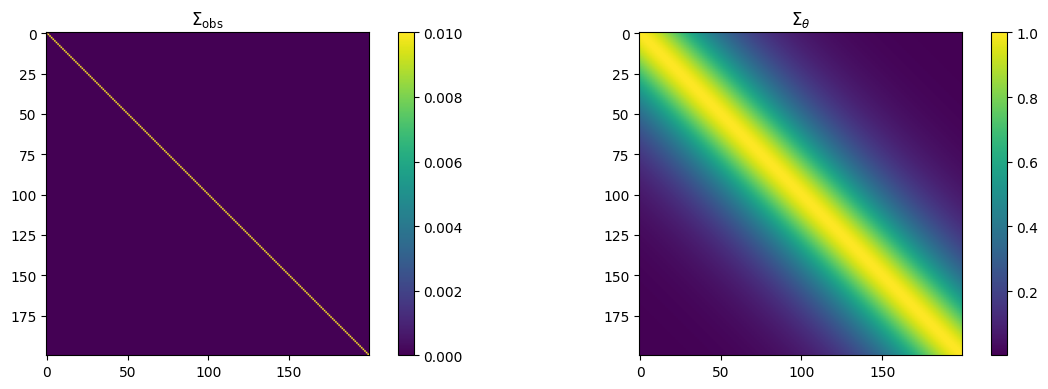

In [397]:
plot_matrices(
    [noise.get_covariance(N), prior.Sigma],
    [r"$\Sigma_{\rm obs}$", r"$\Sigma_\theta$"],
    figsize=(12, 4),
)

## 4. Forward Model

The forward operator $G:(\theta)\mapsto u(\cdot,T)\in\mathbb{R}^N$ runs the
Burgers PDE from the concatenated initial condition $\theta$.

In [398]:
def make_forward_model(pde_model, n_steps):
    """Return the forward operator G(theta, eta) -> u(·, T).

    Parameters
    ----------
    pde_model : object
        PDE solver with an ``evolve(u0, n_steps)`` method.
    n_steps : int
        Number of time steps to run.

    Returns
    -------
    G : callable
        Function ``G(theta) -> ndarray`` of shape ``(N,)``.
    """
    def G(theta: np.ndarray):
        return pde_model.evolve(u0=theta, n_steps=n_steps)[-1, :]
    return G

In [399]:
theta = u0_true.copy()
print(f"theta size : {theta.size}")

G = make_forward_model(pde_model=model, n_steps=n_steps)

# Sanity check: both calling conventions must produce the same output
u1 = G(theta=theta)
print(f"Consistency check ||G(theta,eta) - G(u0)|| = {np.linalg.norm(u1):.2e}")

theta size : 200
Consistency check ||G(theta,eta) - G(u0)|| = 6.42e+00


## 5. Finite-Difference Jacobian

$$
J_\theta(\theta) \in \mathbb{R}^{N\times d},\qquad
J_\theta \approx \frac{G(\theta+h e_j)-G(\theta-h e_j)}{2h}
$$

Cost: $2d$ forward evaluations per sample.

In [400]:
def jacobian_fd(G, theta, h=None):
    """Central finite-difference Jacobian of G with respect to theta.

    Parameters
    ----------
    G     : callable  R^d x R^q -> R^m
    theta : ndarray, shape (d,)
    h     : float, optional
        Step size.  Defaults to ``eps^{1/3} * (||theta|| + 1e-8)``.

    Returns
    -------
    J_theta : ndarray, shape (m, d)
    """
    d = theta.shape[0]
    if h is None:
        h = np.finfo(float).eps ** (1 / 3) * (la.norm(theta) + 1e-8)
    
    G_theta = G(theta)
    m = G_theta.shape[0]
    J = np.zeros((m, d))
    
    for j in range(d):
        e_j = np.zeros(d)
        e_j[j] = 1.0
        J[:, j] = (G(theta + h * e_j) - G(theta - h * e_j)) / (2 * h)
    return J

In [401]:

from functools import partial
J_G = partial(jacobian_fd, G) 


## 6. Monte-Carlo Estimation of $l_\theta$, $l_\eta$, and $l_{(\theta,\eta)}$

$$
l_\theta(u) = \mathbb{E}[J_\theta(\theta)^\top] \in \mathbb{R}^{d\times N}
$$

Samples are drawn from the **prior** $\pi_0(\theta)$ (pre-experimental setting,
no observations yet available).

In [402]:
def estimate_E_JT(G, prior, n_samples, eps=1e-6, n_jobs=-1):
    """
    Monte-Carlo estimate of E[J_theta^T] où J_theta est le Jacobien de G (m x d).
    Retourne une matrice (d, m).
    """
    if n_samples < 1:
        raise ValueError("n_samples must be >= 1")
    
    # Échantillons theta par Halton (quasi-MC) pour meilleure convergence
    theta_samples = sample_prior(prior=prior, n=n_samples, seed=42)  # (n_samples, d)


    # Chaque appel retourne J (m, d)
    Jacobians = Parallel(n_jobs=n_jobs)(
        delayed(jacobian_fd)(G, theta, eps) for theta in theta_samples
        )
    # Somme des transposées (d, m)
    sum_JT = np.sum([J.T for J in Jacobians], axis=0)
    
    return sum_JT / n_samples

l_theta shape : (200, 200)


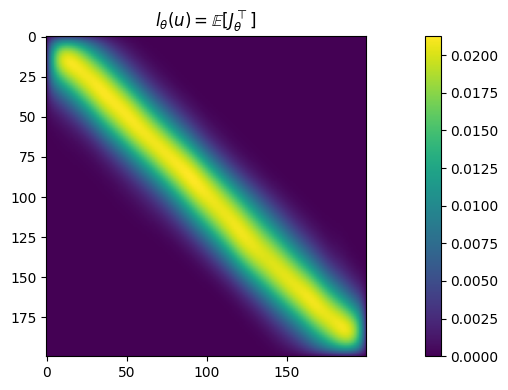

In [403]:
l_theta = estimate_E_JT(G=G, prior=prior, n_samples=n_samples)

print(f"l_theta shape : {l_theta.shape}")

plot_matrices(
    [l_theta],
    [
        r"$l_\theta(u) = \mathbb{E}[J_\theta^\top]$"
    ],
    figsize=(12, 4),
)

## 7. Monte-Carlo Estimation of $\mathcal{H}_\theta^{\Sigma_{\rm obs}}$

$$
\mathcal{H}_\theta^{\Sigma_{\rm obs}}(u)
= \mathrm{Cov}\bigl(J_\theta(\theta)^\top \Sigma_{\rm obs}^{-1/2}\bigr)
$$


In [404]:
def estimate_jacobian_covariances_mc(
    G, prior, Sigma_obs, n_samples,
    h=None, unbiased=False, rng=None, n_jobs=-1, parallel=True
):
    """Parallel version of Monte-Carlo estimation of Cov(Z_theta)."""
    Sigma_obs = np.asarray(Sigma_obs, dtype=float)
    evals, evecs = la.eigh(Sigma_obs)
    if np.any(evals <= 0):
        raise ValueError("Sigma_obs must be symmetric positive definite.")
    Sigma_inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T

    if rng is None:
        rng = np.random.default_rng()

    # Sample thetas using Halton or random
    theta_samples = sample_prior(prior=prior, n=n_samples, seed=142)   # (n_samples, d)

    # Compute all Z_theta in parallel
    def compute_Z(theta):
        J = jacobian_fd(G, theta, h=h)
        return J.T @ Sigma_inv_sqrt   # shape (d, m)

    if parallel:
        Z_theta_list = Parallel(n_jobs=n_jobs)(
            delayed(compute_Z)(theta) for theta in theta_samples
        )
    else:
        Z_theta_list = [compute_Z(theta) for theta in theta_samples]

    Z_theta_arr = np.array(Z_theta_list)  # (n, d, m)

    # Mean and covariance
    Z_theta_mean = np.mean(Z_theta_arr, axis=0)  # (d, m)
    d_theta = Z_theta_mean.shape[0]

    Cov_theta = np.zeros((d_theta, d_theta))

    # Accumulate (can be parallelized but usually small dimension)
    for k in range(n_samples):
        Dt = Z_theta_arr[k] - Z_theta_mean   # (d, m)
        Cov_theta += Dt @ Dt.T                # (d, d)

    denom = (n_samples - 1) if (unbiased and n_samples > 1) else n_samples
    Cov_theta /= denom
    Cov_theta = 0.5 * (Cov_theta + Cov_theta.T)

    return Cov_theta

H_theta shape      : (200, 200)


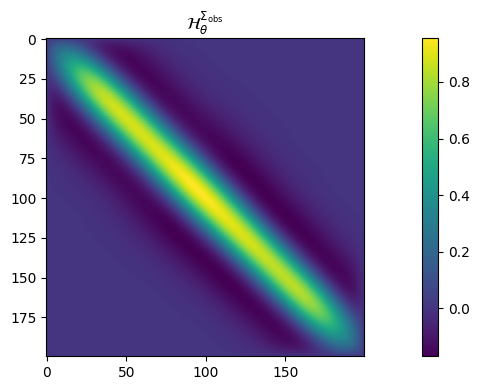

In [405]:
Cov_theta = estimate_jacobian_covariances_mc(
    G=G, prior=prior,
    Sigma_obs=noise.get_covariance(N), n_samples=n_samples,
)

print(f"H_theta shape      : {Cov_theta.shape}")

plot_matrices(
    [Cov_theta],
    [
        r"$\mathcal{H}_\theta^{\Sigma_{\rm obs}}$"
       
    ],
    figsize=(12, 4),
)

## 8. Covariance Matrices

### 8a. Marginal output covariance $\Sigma_Y$

$$
\Sigma_Y = \Sigma_{\rm obs} + \mathrm{Cov}_{\pi_0}[G(\theta,\eta)]
$$

In [406]:
def estimate_Sigma_Y(G, prior, Sigma_obs, n_samples, rng=None):
    """Estimate Sigma_Y = Sigma_obs + Cov_{pi_0}[G(theta)] by Monte Carlo.

    Samples from the joint prior.

    Parameters
    ----------
    G           : callable
    prior       : 'mu', 'Sigma', 'd'
    Sigma_obs   : ndarray (m, m)
    n_samples   : int
    rng         : np.random.Generator or None

    Returns
    -------
    Sigma_Y : ndarray (m, m)
    """
    if rng is None:
        rng = np.random.default_rng()

    m_theta = np.asarray(prior.mu)
    Sigma_theta = np.asarray(prior.Sigma)
    Sigma_obs = np.asarray(Sigma_obs, dtype=float)
    # theta_samples = rng.multivariate_normal(mean=prior.mu, cov=prior.Sigma, size=n_samples)

    sampler = qmc.Halton(d=len(prior.mu))
    samples_unif = sampler.random(n=n_samples)
    u_normal = norm.ppf(samples_unif)
    L = np.linalg.cholesky(prior.Sigma)
    theta_samples = prior.mu + (L @ u_normal.T).T   # (n_samples, d)

    U = Parallel(n_jobs=-1)(
            delayed(G)(theta_samples[k]) for k in range(n_samples))
    U = np.array(U)
    SY = Sigma_obs + np.cov(U, rowvar=False, bias=False)
    return 0.5 * (SY + SY.T)  # symmetrise


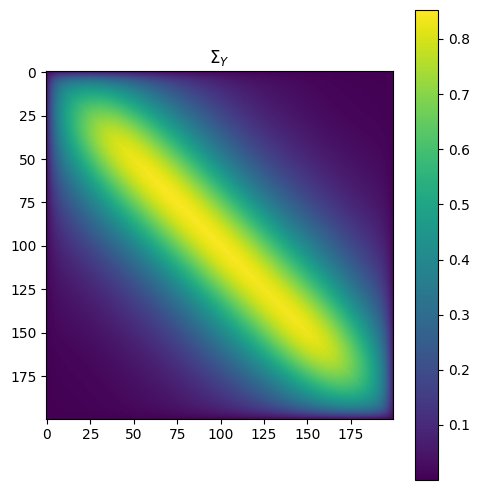

In [407]:
Sigma_Y = estimate_Sigma_Y(
    G=G, prior=prior,
    Sigma_obs=noise.get_covariance(N), n_samples=15000,
)
plot_matrices([Sigma_Y], [r"$\Sigma_Y$"], figsize=(5, 5))

### 8b. Noise covariance $\Sigma_{\rm noise}$

$$
\Sigma_{\rm noise} = \Sigma_{\rm obs}
$$

### 8c. Signal covariance $\Sigma_{\rm signal}$

$$
\Sigma_{\rm signal} = \Sigma_{\rm obs}
+ l_\theta^\top
  \left(\Sigma_\theta^{-1} + \mathcal{H}_\theta^{\Sigma_{\rm obs}}\right)^{-1}
  l_\theta
$$

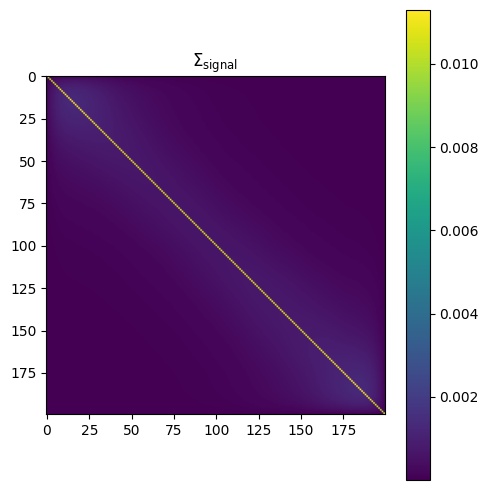

In [408]:
def compute_Sigma_signal(l_theta, H_theta, Sigma_theta, Sigma_obs):
    """Compute the signal covariance matrix.

    Parameters
    ----------
    l_theta    : ndarray (d, m)  — l_theta(u) or l_{(theta,eta)}(u)
    H_theta    : ndarray (d, d)  — H_theta^{Sigma_obs} (or full block)
    Sigma_theta: ndarray (d, d)  — prior covariance (or full joint covariance)
    Sigma_obs  : ndarray (m, m)

    Returns
    -------
    Sigma_signal : ndarray (m, m)
    """
    A = la.inv(Sigma_theta) + H_theta
    X = la.solve(A, l_theta)
    return Sigma_obs + l_theta.T @ X


Sigma_signal = compute_Sigma_signal(
    l_theta=l_theta,
    H_theta=Cov_theta,
    Sigma_theta=prior.Sigma,
    Sigma_obs=noise.get_covariance(N),
)

plot_matrices([Sigma_signal], [r"$\Sigma_{\rm signal}$"], figsize=(5, 5))

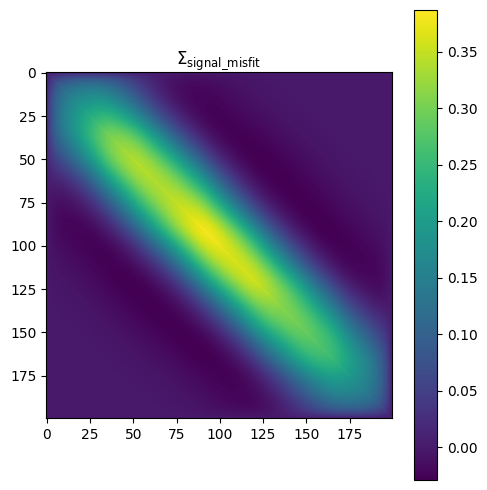

In [409]:
def compute_Sigma_signal_misfit(l_theta, H_theta, Sigma_theta, Sigma_obs):
    """
    Compute the signal covariance matrix.

    Parameters
    ----------
    l_theta     : ndarray (d, m)
    H_theta     : ndarray (d, d)
    Sigma_theta : ndarray (d, d)
    Sigma_obs   : ndarray (m, m)

    Returns
    -------
    Sigma_signal : ndarray (m, m)
    """

    # Symmetric square root of Sigma_theta
    eigvals, eigvects = np.linalg.eigh(Sigma_theta)

    # Numerical safeguard
    eigvals = np.clip(eigvals, 0.0, None)

    Sigma_theta_sqrt = (
        eigvects
        @ np.diag(np.sqrt(eigvals))
        @ eigvects.T
    )

    H_misfit = (
        Sigma_theta_sqrt
        @ H_theta
        @ Sigma_theta_sqrt
    )

    I_plus_H_misfit = np.eye(H_misfit.shape[0]) + H_misfit

    A = (
        Sigma_theta_sqrt
        @ la.solve(I_plus_H_misfit, Sigma_theta_sqrt)
    )

    X = la.solve(A, l_theta)

    return Sigma_obs + l_theta.T @ X


Sigma_signal_misfit = compute_Sigma_signal_misfit(
    l_theta=l_theta,
    H_theta=Cov_theta,
    Sigma_theta=prior.Sigma,
    Sigma_obs=noise.get_covariance(N),
)

plot_matrices([Sigma_signal_misfit], [r"$\Sigma_{\rm signal\_misfit}$"], figsize=(5, 5))

### 8d. Conditional output covariance $\Sigma_{Y|\theta}$

$$
\Sigma_{Y|\theta} = \Sigma_{\rm obs}
$$

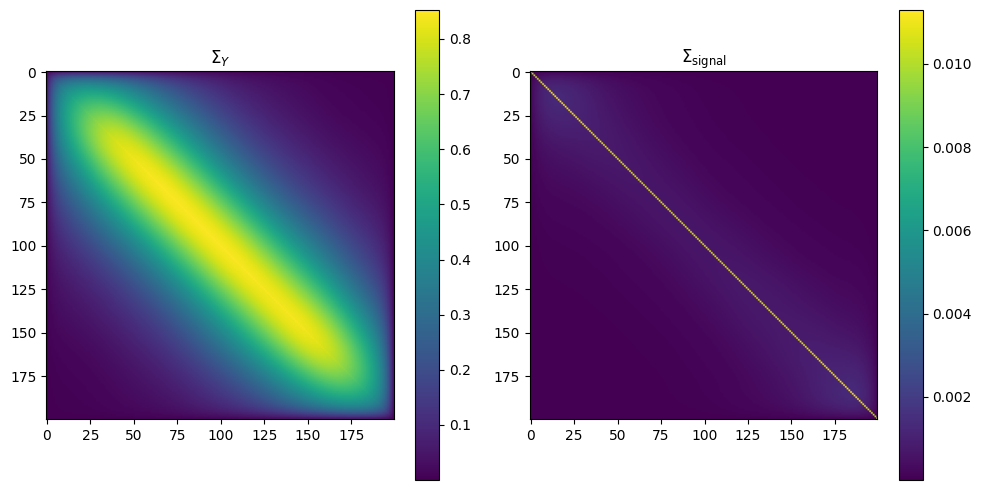

relative error 2 Sigma_Y, Sigma_signal : 98.49181041926016 %
relative error fro Sigma_Y, Sigma_signal : 99.88951094542409 %


In [410]:
plot_matrices([Sigma_Y,Sigma_signal], [r"$\Sigma_{Y}$",r"$\Sigma_{\rm signal}$"], figsize=(10, 5))
print(f"relative error 2 Sigma_Y, Sigma_signal : {np.linalg.norm(Sigma_Y-Sigma_signal,ord='nuc')*100/np.linalg.norm(Sigma_Y,ord='nuc')} %")
print(f"relative error fro Sigma_Y, Sigma_signal : {np.linalg.norm(Sigma_Y-Sigma_signal,ord='fro')*100/np.linalg.norm(Sigma_Y,ord='fro')} %")

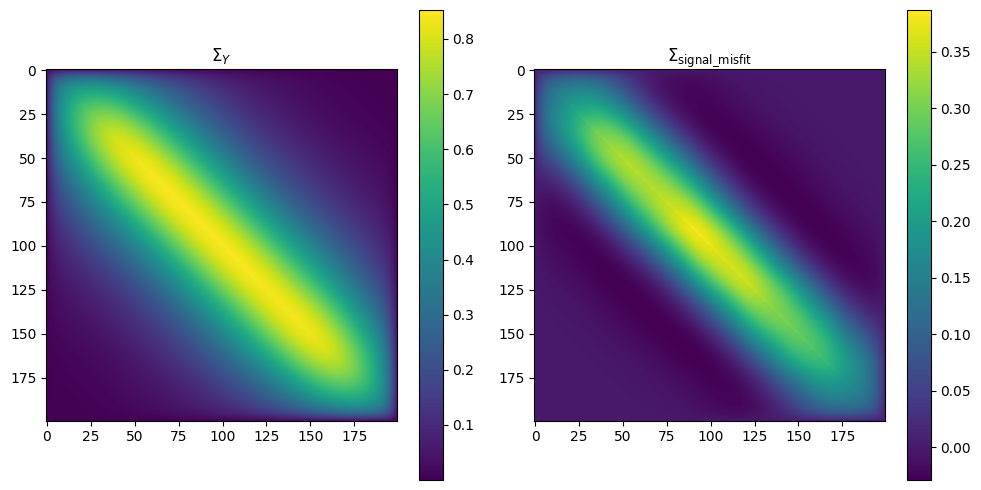

relative error 2 Sigma_Y, Sigma_signal : 61.824083212276996 %
relative error fro Sigma_Y, Sigma_signal : 72.1311486622172 %


In [411]:
plot_matrices([Sigma_Y,Sigma_signal_misfit], [r"$\Sigma_{Y}$",r"$\Sigma_{\rm signal\_misfit}$"], figsize=(10, 5))
print(f"relative error 2 Sigma_Y, Sigma_signal : {np.linalg.norm(Sigma_Y-Sigma_signal_misfit,ord='nuc')*100/np.linalg.norm(Sigma_Y,ord='nuc')} %")
print(f"relative error fro Sigma_Y, Sigma_signal : {np.linalg.norm(Sigma_Y-Sigma_signal_misfit,ord='fro')*100/np.linalg.norm(Sigma_Y,ord='fro')} %")

## 10. EIG Estimators

For a sensor-selection matrix $W \in \mathbb{R}^{N\times s}$, we define the
**relative** EIG gain (over the full-observation design $I_N$):

$$
\Delta\mathrm{EIG}(W) = \mathrm{EIG}(W) - \mathrm{EIG}(I_N)
= \frac{1}{2}\log\frac{\det(W^\top A\, W)}{\det(W^\top B\, W)}
  - \frac{1}{2}\log\frac{\det(A)}{\det(B)}
$$

where $(A,B)$ is $(\Sigma_{\rm signal}, \Sigma_{\rm obs})$ for the **upper bound (BS)**
and $(\Sigma_Y, \Sigma_{\rm obs})$ for the **direct estimator (BI)**.

### 10a. Upper bound (BS) — based on $\Sigma_{\rm signal}$ and $\Sigma_{\rm Y|\theta}$

### 10a. MC reference EIG estimator

In [412]:


# ----------------------------------------------------------------------
# 2.  Estimateur principal : KL + marginale analytique + correction
# ----------------------------------------------------------------------
def estimate_eig_kl(G, J_G, kl_prior, Sigma_obs, n_outer, seed=None, n_jobs=-1):
    """
    Estimateur sans biais (à la linéarisation près) pour l'EIG.
    Fonctionne pour G linéaire ou faiblement non‑linéaire.
    """
    G_r   = kl_prior.make_G_reduced(G)
    J_r   = kl_prior.make_J_reduced(J_G)
    k     = kl_prior.k
    m     = len(Sigma_obs)

    # pré‑calculs pour Sigma_obs
    L_obs    = sla.cholesky(Sigma_obs, lower=True)
    Sinv_obs = sla.cho_solve((L_obs, True), np.eye(m))
    _, ld    = la.slogdet(Sigma_obs)
    log_c    = -0.5 * (ld + m * np.log(2 * np.pi))

    # seeds reproductibles
    ss    = np.random.SeedSequence(seed)
    seeds = ss.spawn(n_outer)

    def _step(seed_i):
        rng = np.random.default_rng(seed_i)

        # 1. xi ~ N(0, I_k)
        xi = rng.standard_normal(k)
        Gr = np.asarray(G_r(xi))
        Jr = np.asarray(J_r(xi))

        # 2. Matrice marginale S = Jr Jr^T + Sigma_obs
        S      = Jr @ Jr.T + Sigma_obs
        L_S    = sla.cholesky(S, lower=True)
        Sinv_S = sla.cho_solve((L_S, True), np.eye(m))
        _, ld_S = la.slogdet(S)
        log_c_S = -0.5 * (ld_S + m * np.log(2 * np.pi))

        # 3. Correction du biais quadratique
        #    = ½ tr( (S^{-1} - Σ_obs^{-1}) Σ_obs )
        bias_corr = 0.5 * (np.trace(Sinv_S @ Sigma_obs) - m)

        # 4. Simuler y
        eps = rng.multivariate_normal(np.zeros(m), Sigma_obs)
        y   = Gr + eps

        # 5. log p(y | xi)
        log_lik = log_c - 0.5 * np.dot(eps, Sinv_obs @ eps)

        # 6. log p(y) par marginale analytique
        r = y - Gr
        log_py = log_c_S - 0.5 * r @ Sinv_S @ r

        return float(log_lik - log_py - bias_corr)

    results = Parallel(n_jobs=n_jobs)(
        delayed(_step)(seeds[i]) for i in range(n_outer)
    )
    return float(np.mean(results))


In [413]:
# Version avec gestion mémoire seule
# BASE_SEED = 102
list_eig = []
for BASE_SEED in [1042]:

    eig_mem = estimate_eig_kl(G, J_G, kl_prior, 
                    Sigma_obs, 500, 
                        seed=BASE_SEED, n_jobs=-1)
    list_eig.append(eig_mem)

    print(f"eig BASE SEED {BASE_SEED}: {eig_mem}")
eig_mem = np.mean(np.array(list_eig))
print(f"eig moyenne: {eig_mem}")

eig BASE SEED 1042: 25.003053009970824
eig moyenne: 25.003053009970824


In [414]:
import warnings
def estimate_eig_kl_dlmcis(G, J_G, kl_prior, Sigma_obs, n_outer,
                           Ne=1, M_inner=10, seed=None, n_jobs=-1):
    """
    Estimate EIG using DLMCIS (Laplace-based importance sampling) from the paper.
    Uses the reduced prior (standard normal) via kl_prior.

    Parameters
    ----------
    G : callable
        Original model function G(theta) -> array (q,)
    J_G : callable
        Original Jacobian function J_G(theta) -> array (q, d)
    kl_prior : object
        Prior object with methods make_G_reduced, make_J_reduced, and attribute k
    Sigma_obs : ndarray (q, q)
        Observation noise covariance
    n_outer : int
        Number of outer samples (N)
    Ne : int, default=1
        Number of repeated experiments (i.i.d. replicates)
    M_inner : int, default=10
        Number of inner importance samples per outer sample (M)
    seed : int or None, default=None
        Random seed for reproducibility
    n_jobs : int, default=-1
        Number of parallel jobs (joblib)

    Returns
    -------
    eig_estimate : float
        Estimated expected information gain (nats)
    """
    # Build reduced functions (xi space, prior N(0,I))
    G_r = kl_prior.make_G_reduced(G)   # G_r(xi) -> (q,)
    J_r = kl_prior.make_J_reduced(J_G) # J_r(xi) -> (q, k)
    k = kl_prior.k                    # dimension of xi
    q = Sigma_obs.shape[0]

    # Pre‑compute Cholesky and log‑det of Sigma_obs
    L_obs = sla.cholesky(Sigma_obs, lower=True)
    log_det_obs = 2 * np.sum(np.log(np.diag(L_obs)))
    log_const_lik = -0.5 * (q * np.log(2 * np.pi) + log_det_obs)

    # Log‑prior in reduced space: xi ~ N(0, I)
    def log_prior_red(xi):
        return -0.5 * (xi @ xi + k * np.log(2 * np.pi))

    # Log‑likelihood for a single replicate
    def log_lik_single(y, xi):
        r = y - G_r(xi)
        return log_const_lik - 0.5 * r @ sla.solve_triangular(L_obs, r, lower=True)

    # Log‑likelihood for Ne i.i.d. replicates
    def log_lik(Y, xi):
        ll = 0.0
        for i in range(Ne):
            ll += log_lik_single(Y[i], xi)
        return ll

    # Negative log‑posterior for MAP optimisation
    def neg_log_posterior(xi, Y):
        return -log_lik(Y, xi) - log_prior_red(xi)

    # Hessian of negative log‑posterior at MAP (Laplace approximation)
    def hessian_laplace(xi_map, Y):
        J = J_r(xi_map)                     # (q, k)
        # Fisher information: Ne * J^T Sigma^{-1} J
        R = sla.cholesky(Sigma_obs, lower=True)
        RJ = sla.solve_triangular(R, J, lower=True)  # (q, k)
        Fisher = Ne * RJ.T @ RJ              # (k, k)
        # Hessian of log‑prior is -I, so -hess_log_prior = I
        H = Fisher + np.eye(k)
        return H

    # Outer loop (parallelised)
    rng = np.random.default_rng(seed)

    def process_outer(seed_i):
        local_rng = np.random.default_rng(seed_i)

        # 1. Sample xi from prior N(0, I)
        xi_n = local_rng.standard_normal(k)

        # 2. Generate Ne observations Y using true xi_n
        Y_n = np.zeros((Ne, q))
        for i in range(Ne):
            eps = local_rng.multivariate_normal(np.zeros(q), Sigma_obs)
            Y_n[i] = G_r(xi_n) + eps

        # 3. Find MAP estimate xi_hat by minimising negative log‑posterior
        from scipy.optimize import minimize
        res = minimize(neg_log_posterior, xi_n, args=(Y_n,), method='L-BFGS-B')
        if not res.success:
            warnings.warn(f"MAP optimisation failed: {res.message}")
        xi_hat = res.x

        # 4. Laplace covariance = inverse of Hessian at MAP
        H = hessian_laplace(xi_hat, Y_n)
        try:
            L_laplace = sla.cholesky(H, lower=True)
            Sigma_laplace = sla.solve_triangular(L_laplace, np.eye(k), lower=True)
            Sigma_laplace = Sigma_laplace @ Sigma_laplace.T
        except np.linalg.LinAlgError:
            H_reg = H + 1e-6 * np.eye(k)
            L_laplace = sla.cholesky(H_reg, lower=True)
            Sigma_laplace = sla.solve_triangular(L_laplace, np.eye(k), lower=True)
            Sigma_laplace = Sigma_laplace @ Sigma_laplace.T

        # 5. Inner importance sampling
        log_weights = np.zeros(M_inner)
        for m in range(M_inner):
            xi_tilde = local_rng.multivariate_normal(xi_hat, Sigma_laplace)
            log_lik_val = log_lik(Y_n, xi_tilde)
            log_prior_val = log_prior_red(xi_tilde)
            log_prop = multivariate_normal.logpdf(xi_tilde, mean=xi_hat, cov=Sigma_laplace)
            log_weights[m] = log_lik_val + log_prior_val - log_prop

        # Stable log‑evidence via log‑sum‑exp
        max_logw = np.max(log_weights)
        log_evidence = max_logw + np.log(np.mean(np.exp(log_weights - max_logw)))

        # 6. Contribution to EIG
        log_lik_xi_n = log_lik(Y_n, xi_n)
        return log_lik_xi_n - log_evidence

    # Parallel execution of outer loop
    if seed is not None:
        ss = np.random.SeedSequence(seed)
        seeds = ss.spawn(n_outer)
    else:
        seeds = [None] * n_outer

    results = Parallel(n_jobs=n_jobs)(delayed(process_outer)(seeds[i]) for i in range(n_outer))
    return float(np.mean(results))

In [415]:
# # Exemple avec vos objets G, J_G, kl_prior, Sigma_obs
# eig = estimate_eig_kl_dlmcis(G, J_G, kl_prior, Sigma_obs, n_outer=100,
#                              Ne=2, M_inner=10, seed=123, n_jobs=-1)
# print(f"EIG = {eig:.4f} nats")


In [416]:
def eig_linearise(J, prior, Sigma_obs):
    S = Sigma_obs + J @ prior.Sigma @ J.T
    _, ldet_S   = np.linalg.slogdet(S)
    _, ldet_obs = np.linalg.slogdet(Sigma_obs)
    return 0.5 * (ldet_S - ldet_obs)

In [417]:
# J = jacobian_fd(G, prior.mu)
# eig_mem = eig_linearise(J, prior, Sigma_obs)
# print(f"EIG linéarisé : {eig_mem:.4f}")
# print(f"EIG exact     : 22.3258")

### 10a. Upper bound (BS) — based on $\Sigma_{\rm signal}$ and $\Sigma_{Y|\theta}$

In [418]:
def eig_BS(Sigma_signal, Sigma_Y_given_theta, W):
    """EIG upper bound (BS) relative to the full-observation design.

    Parameters
    ----------
    Sigma_signal : ndarray (m, m)
    Sigma_noise  : ndarray (m, m)
    W            : ndarray (m, s)  — sensor selection matrix

    Returns
    -------
    float  — Delta EIG_BS(W)
    """
    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_Y_given_theta.shape[0])
    return 0.5 * (log_ratio(Sigma_signal, Sigma_Y_given_theta, W)
                  - log_ratio(Sigma_signal, Sigma_Y_given_theta, eye))

### 10b. Direct estimator (BI) — based on $\Sigma_Y$ and $\Sigma_{\rm noise}$

In [419]:
def eig_BI(Sigma_Y, Sigma_noise, W):
    """EIG direct estimator (BI) relative to the full-observation design.

    Parameters
    ----------
    Sigma_Y      : ndarray (m, m)
    Sigma_noise  : ndarray (m, m)
    W            : ndarray (m, s)  — sensor selection matrix

    Returns
    -------
    float  — Delta EIG_BI(W)
    """
    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_noise.shape[0])
    return 0.5 * (log_ratio(Sigma_Y, Sigma_noise, W)
                  - log_ratio(Sigma_Y, Sigma_noise, eye))

## 11. Greedy Sensor Placement and Comparison

We greedily maximise the BI lower bound to select a budget of sensors,
then evaluate both estimators on the resulting design.

In [420]:
def greedy_maximize_LB(Sigma_Y, Sigma_noise, n_sensors):
    """
    Greedy forward sensor selection maximizing
    0.5 * log det(Sigma_Y) - 0.5 * log det(Sigma_noise)
    """

    Sigma_Y = 0.5 * (Sigma_Y + Sigma_Y.T)
    Sigma_noise = 0.5 * (Sigma_noise + Sigma_noise.T)

    N = Sigma_Y.shape[0]

    selected = []
    remaining = set(range(N))

    def logdet_spd(A):
        L = np.linalg.cholesky(A)
        return 2.0 * np.sum(np.log(np.diag(L)))

    for _ in range(n_sensors):

        best_idx = None
        best_score = -np.inf

        for idx in remaining:

            S = selected + [idx]
            ix = np.ix_(S, S)

            logdet_y = logdet_spd(Sigma_Y[ix])
            logdet_n = logdet_spd(Sigma_noise[ix])

            score = 0.5 * (logdet_y - logdet_n)

            if score > best_score:
                best_score = score
                best_idx = idx

        selected.append(best_idx)
        remaining.remove(best_idx)

    return np.array(selected, dtype=int)

### Incremental bounds

In [421]:
def schur(Sigma, Wm):
    if Wm.size == 0:
        return Sigma

    G = Wm.T @ Sigma @ Wm
    correction = Sigma @ Wm @ np.linalg.solve(G, Wm.T @ Sigma)

    return Sigma - correction


def incremental_bounds(
    Sigma_signal:  np.ndarray,
    Sigma_Y_theta: np.ndarray,
    Sigma_Y:       np.ndarray,
    Sigma_noise:   np.ndarray,
    n_sensors:     int,
):
    N = Sigma_Y.shape[0]
    W_candidates = [np.eye(N)[:, i] for i in range(N)]

    selected   = []
    remaining  = list(range(N))

    inc_inf = []
    inc_sup = []

    eig_inf = 0.0
    eig_sup = 0.0

    for m in range(n_sensors):

        # W_m
        if selected:
            Wm = np.column_stack([W_candidates[i] for i in selected])
        else:
            Wm = np.empty((N, 0))

        # matrices conditionnelles
        Sigma_s_m   = schur(Sigma_signal,  Wm)
        Sigma_yth_m = schur(Sigma_Y_theta, Wm)
        Sigma_Y_m   = schur(Sigma_Y,       Wm)
        Sigma_n_m   = schur(Sigma_noise,   Wm)

        best_idx = None
        best_inc = -np.inf
        best_sup = None

        for idx in remaining:
            w = W_candidates[idx]

            num_inf = float(w.T @ Sigma_s_m   @ w)
            den_inf = float(w.T @ Sigma_yth_m @ w)

            num_sup = float(w.T @ Sigma_Y_m @ w)
            den_sup = float(w.T @ Sigma_n_m @ w)

            if min(num_inf, den_inf, num_sup, den_sup) <= 0:
                continue

            d_inf = 0.5 * np.log(num_inf / den_inf)
            d_sup = 0.5 * np.log(num_sup / den_sup)

            if d_inf > best_inc:
                best_inc = d_inf
                best_sup = d_sup
                best_idx = idx

        if best_idx is None:
            break

        selected.append(best_idx)
        remaining.remove(best_idx)

        eig_inf += best_inc
        eig_sup += best_sup

        inc_inf.append(best_inc)
        inc_sup.append(best_sup)

    return {
        "indices": np.array(selected, dtype=int),
        "increments_lower": inc_inf,
        "increments_upper": inc_sup,
        "EIG_lower_bound": eig_inf,
        "EIG_upper_bound": eig_sup,
    }

In [422]:
def incremental_bounds_given_W(
    Sigma_signal:  np.ndarray,
    Sigma_Y_theta: np.ndarray,
    Sigma_Y:       np.ndarray,
    Sigma_noise:   np.ndarray,
    W:             np.ndarray
) -> tuple[float, float]:

    # Lower bound
    _, logdet_sig = np.linalg.slogdet(W.T @ Sigma_signal  @ W)
    _, logdet_th  = np.linalg.slogdet(W.T @ Sigma_Y_theta @ W)
    lb = 0.5 * (logdet_sig - logdet_th)

    # Upper bound
    _, logdet_Y = np.linalg.slogdet(W.T @ Sigma_Y     @ W)
    _, logdet_n = np.linalg.slogdet(W.T @ Sigma_noise @ W)
    ub = 0.5 * (logdet_Y - logdet_n)

    return lb, ub

### Greedy sensor placement: BI vs incremental bounds comparison

We select sensors greedily (maximising BI), then evaluate both the global BI/BS bounds
and the incremental bounds on the resulting design.

In [423]:
SS = Sigma_signal_misfit

In [424]:
sensor_budgets = [5, 10,15,20,25]
lb_vals_cons = []
ub_vals_cons = []

lb_vals_inc = []
ub_vals_inc = []

Sigma_obs = noise.get_covariance(N)

for budget in sensor_budgets:
    result = incremental_bounds(
        Sigma_signal  = SS,
        Sigma_Y_theta = Sigma_obs,
        Sigma_Y       = Sigma_Y,
        Sigma_noise   = Sigma_obs,
        n_sensors     = budget,       
    )
    W_opt_get_incremental, _ = build_selection_matrices(N, result['indices'])

    lb = eig_BI(Sigma_Y, Sigma_obs, W_opt_get_incremental)
    ub = eig_BS(SS, Sigma_obs, W_opt_get_incremental)

    lb_vals_cons.append(lb)
    ub_vals_cons.append(ub)

    lb_vals_inc.append(result["EIG_lower_bound"])
    ub_vals_inc.append(result["EIG_upper_bound"])


eig : 25.003053009970824
[ 1.23155886  5.84445167  7.74559172  9.29065418 10.66296036]


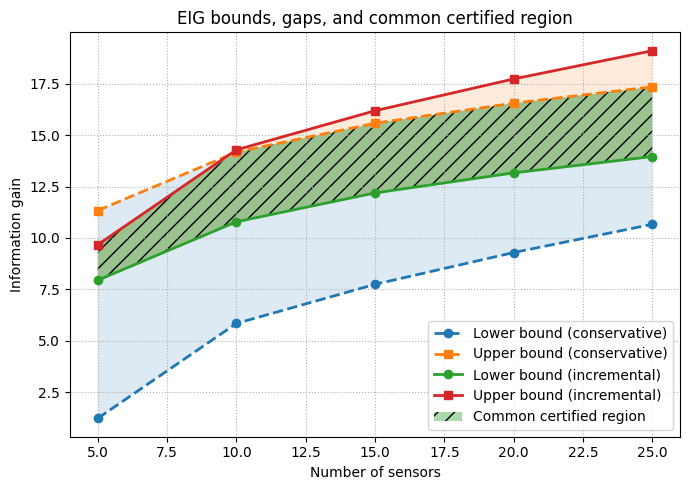

In [425]:
offset = eig_mem # mémoire spectrale
print(f"eig : {offset}")

# Bornes conservatrices
lb_cons_1 = np.array(lb_vals_cons) + offset
ub_cons_1 = np.array(ub_vals_cons) + offset
print(lb_cons_1)

# Bornes incrémentales
lb_inc_1 = np.array(lb_vals_inc)
ub_inc_1 = np.array(ub_vals_inc)

# Intersection des intervalles
lb_common = np.maximum(lb_cons_1, lb_inc_1)
ub_common = np.minimum(ub_cons_1, ub_inc_1)
mask = lb_common <= ub_common


# ===============================
# Figure
# ===============================

fig, ax = plt.subplots(figsize=(7, 5))

# --- Conservatif
ax.plot(sensor_budgets, lb_cons_1,
        '--o', linewidth=2,
        label='Lower bound (conservative)')
ax.plot(sensor_budgets, ub_cons_1,
        '--s', linewidth=2,
        label='Upper bound (conservative)')

ax.fill_between(sensor_budgets,
                lb_cons_1, ub_cons_1,
                alpha=0.15)

# --- Incrémental
ax.plot(sensor_budgets, lb_inc_1,
        '-o', linewidth=2,
        label='Lower bound (incremental)')
ax.plot(sensor_budgets, ub_inc_1,
        '-s', linewidth=2,
        label='Upper bound (incremental)')

ax.fill_between(sensor_budgets,
                lb_inc_1, ub_inc_1,
                alpha=0.15)

# --- Zone commune (mise en valeur)
ax.fill_between(sensor_budgets,
                lb_common, ub_common,
                where=mask,
                interpolate=True,
                alpha=0.4,
                hatch='//',
                label='Common certified region')

# ===============================
# Mise en forme
# ===============================

ax.set_xlabel("Number of sensors")
ax.set_ylabel("Information gain")
ax.set_title("EIG bounds, gaps, and common certified region")

ax.grid(True, which='both', linestyle=':', linewidth=0.8)
ax.legend(frameon=True)

fig.tight_layout()
plt.show()

### Sanity check: greedy BI design — global bounds only

In [426]:
sensor_budgets = [5, 10,15,20,25]
lb_vals = []
ub_vals = []

lb_vals_inc = []
ub_vals_inc = []
Sigma_obs = noise.get_covariance(N)

for budget in sensor_budgets:
    indices = greedy_maximize_LB(
        Sigma_Y=Sigma_Y,
        Sigma_noise=Sigma_obs,
        n_sensors=budget
    )
    W_opt_get_conservative, _ = build_selection_matrices(N, indices)

    lb = eig_BI(Sigma_Y, Sigma_obs, W_opt_get_conservative)
    ub = eig_BS(SS, Sigma_obs, W_opt_get_conservative)

    lb_inc, ub_inc = incremental_bounds_given_W(
        Sigma_signal  = SS,
        Sigma_Y_theta = Sigma_obs,
        Sigma_Y       = Sigma_Y,
        Sigma_noise   = Sigma_obs,
        W = W_opt_get_conservative,       
    )

    lb_vals.append(lb)
    ub_vals.append(ub)

    lb_vals_inc.append(lb_inc)
    ub_vals_inc.append(ub_inc)
    # print(60*"*")
    # print(indices)

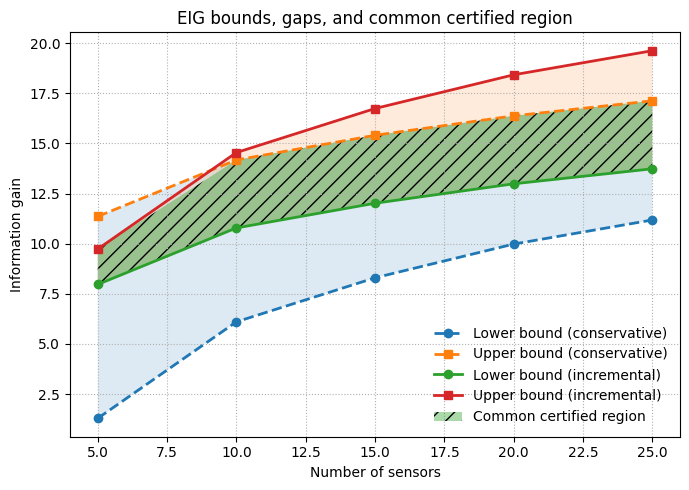

In [427]:
# ===============================
# Préparation des données
# ===============================

offset = eig_mem  # mémoire spectrale

# Bornes conservatrices
lb_cons = np.array(lb_vals) + offset
ub_cons = np.array(ub_vals) + offset

# Bornes incrémentales
lb_inc = np.array(lb_vals_inc)
ub_inc = np.array(ub_vals_inc)

# Intersection des intervalles
lb_common = np.maximum(lb_cons, lb_inc)
ub_common = np.minimum(ub_cons, ub_inc)
mask = lb_common <= ub_common


# ===============================
# Figure
# ===============================

fig, ax = plt.subplots(figsize=(7, 5))

# --- Conservatif
ax.plot(sensor_budgets, lb_cons,
        '--o', linewidth=2,
        label='Lower bound (conservative)')
ax.plot(sensor_budgets, ub_cons,
        '--s', linewidth=2,
        label='Upper bound (conservative)')

ax.fill_between(sensor_budgets,
                lb_cons, ub_cons,
                alpha=0.15)

# --- Incrémental
ax.plot(sensor_budgets, lb_inc,
        '-o', linewidth=2,
        label='Lower bound (incremental)')
ax.plot(sensor_budgets, ub_inc,
        '-s', linewidth=2,
        label='Upper bound (incremental)')

ax.fill_between(sensor_budgets,
                lb_inc, ub_inc,
                alpha=0.15)

# --- Zone commune (mise en valeur)
ax.fill_between(sensor_budgets,
                lb_common, ub_common,
                where=mask,
                interpolate=True,
                alpha=0.4,
                hatch='//',
                label='Common certified region')

# ===============================
# Mise en forme
# ===============================S, Sigma_obs

ax.set_xlabel("Number of sensors")
ax.set_ylabel("Information gain")
ax.set_title("EIG bounds, gaps, and common certified region")

ax.grid(True, which='both', linestyle=':', linewidth=0.8)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()